In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("..\data\heart_disease.csv")

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target_binary
0,63.0,1,1,145.0,233.0,1,2,150.0,0,2.3,3,0.0,6.0,0,0
1,67.0,1,4,160.0,286.0,0,2,108.0,1,1.5,2,3.0,3.0,2,1
2,67.0,1,4,120.0,229.0,0,2,129.0,1,2.6,2,2.0,7.0,1,1
3,37.0,1,3,130.0,250.0,0,0,187.0,0,3.5,3,0.0,3.0,0,0
4,41.0,0,2,130.0,204.0,0,2,172.0,0,1.4,1,0.0,3.0,0,0


In [4]:
df.shape

(1024, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1024 entries, 0 to 1023
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            1024 non-null   float64
 1   sex            1024 non-null   int64  
 2   cp             1024 non-null   int64  
 3   trestbps       1024 non-null   float64
 4   chol           1024 non-null   float64
 5   fbs            1024 non-null   int64  
 6   restecg        1024 non-null   int64  
 7   thalach        1024 non-null   float64
 8   exang          1024 non-null   int64  
 9   oldpeak        1024 non-null   float64
 10  slope          1024 non-null   int64  
 11  ca             1024 non-null   float64
 12  thal           1024 non-null   float64
 13  num            1024 non-null   int64  
 14  target_binary  1024 non-null   int64  
dtypes: float64(7), int64(8)
memory usage: 120.1 KB


In [6]:
df['target_binary'].value_counts()

target_binary
0    554
1    470
Name: count, dtype: int64

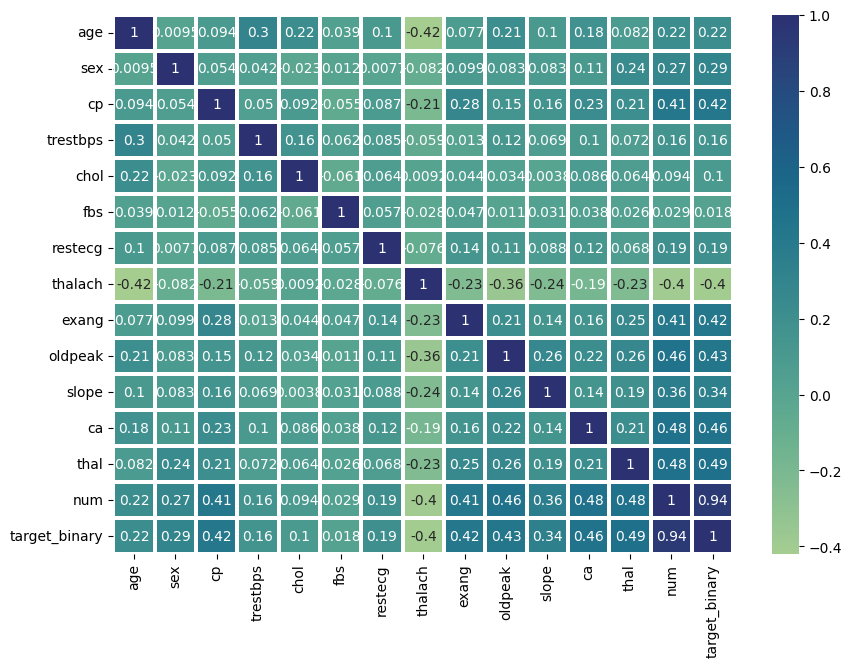

In [7]:
plt.figure(figsize=(10,7))

sns.heatmap(df.corr(),annot=True,linewidths=1.5, cmap='crest')

plt.show()

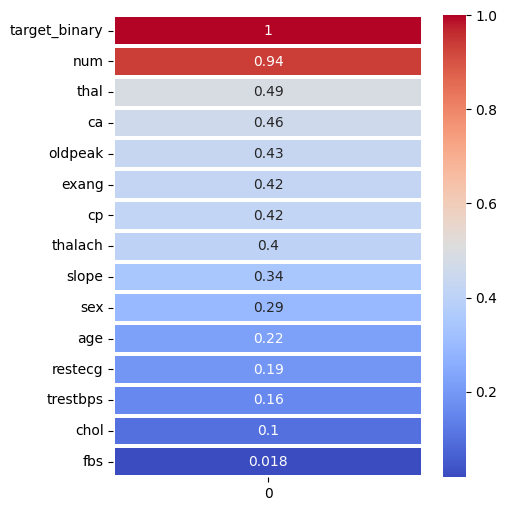

In [8]:
corr = df.corrwith(df['target_binary']).abs().sort_values(ascending=False).to_frame()

plt.figure(figsize=(5,6))
sns.heatmap(corr,linewidths=1.5,annot=True,cmap='coolwarm')

plt.show()

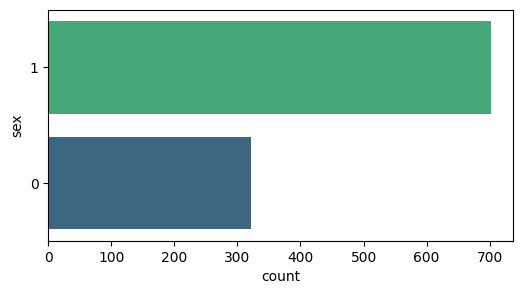

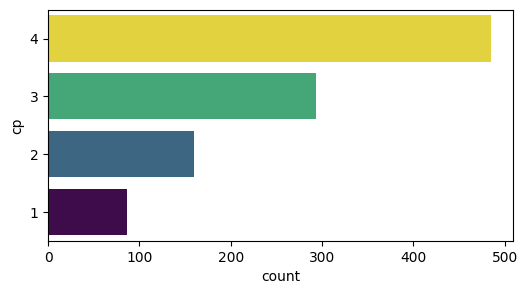

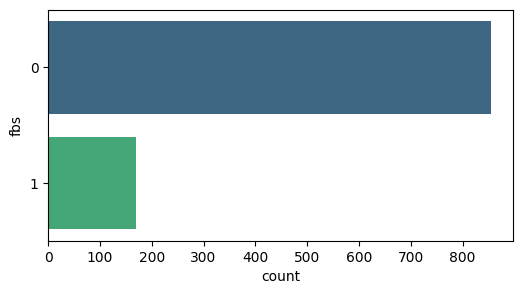

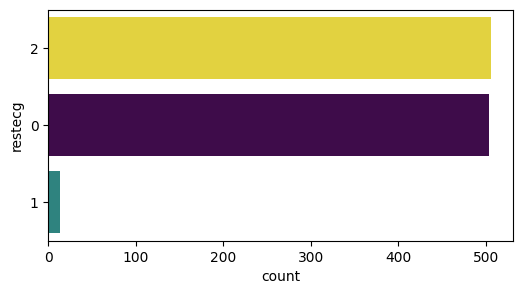

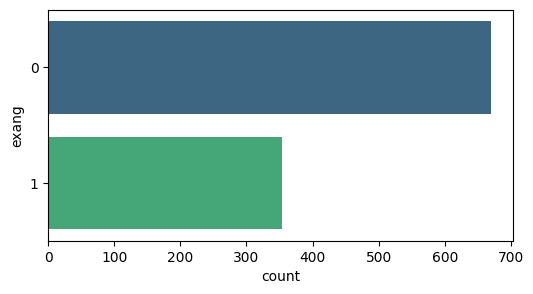

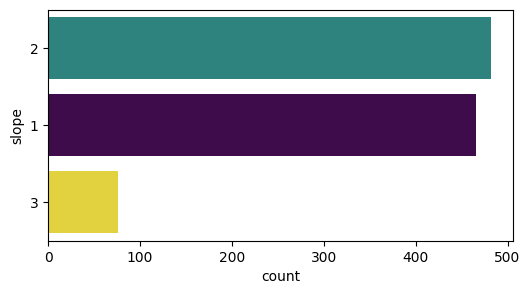

In [9]:
lio = ['sex','cp','fbs','restecg','exang','slope']
for l in lio:
    plt.figure(figsize=(6,3))
    sns.countplot(data=df,y=l,order=df[l].value_counts().index,palette='viridis',hue=l,legend=False)


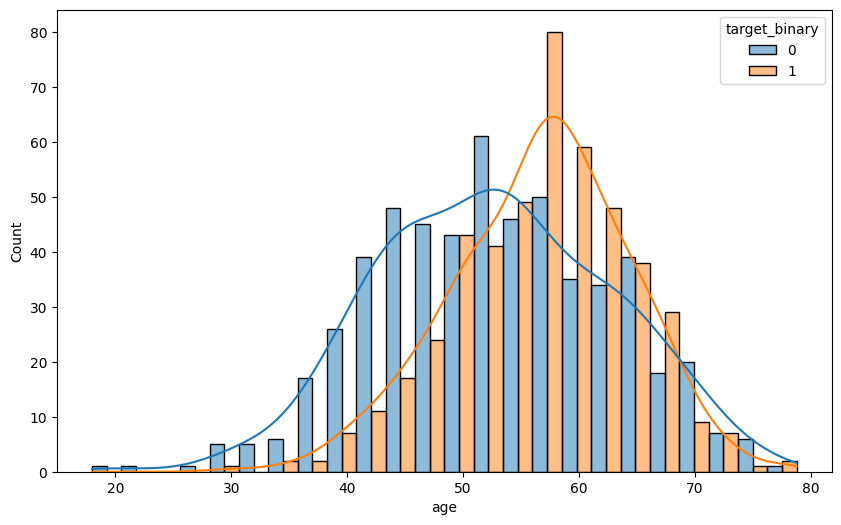

In [10]:
plt.figure(figsize=(10,6))

sns.histplot(data=df,x='age',hue='target_binary',multiple='dodge',kde=True)

plt.show()

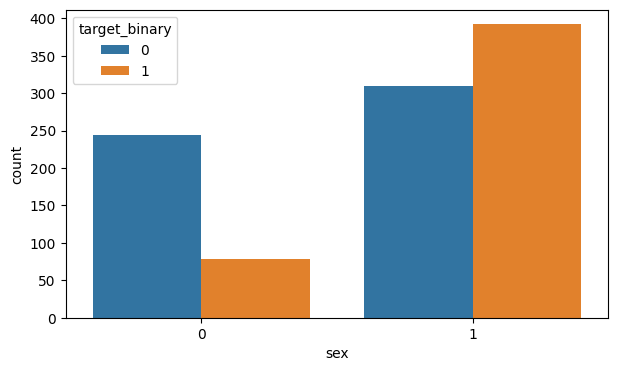

In [11]:
plt.figure(figsize=(7,4))
sns.countplot(data=df,x='sex',hue='target_binary')
plt.show()

In [12]:
df.drop('num',axis=1,inplace=True)
df.head(20)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target_binary
0,63.0,1,1,145.0,233.0,1,2,150.0,0,2.3,3,0.0,6.0,0
1,67.0,1,4,160.0,286.0,0,2,108.0,1,1.5,2,3.0,3.0,1
2,67.0,1,4,120.0,229.0,0,2,129.0,1,2.6,2,2.0,7.0,1
3,37.0,1,3,130.0,250.0,0,0,187.0,0,3.5,3,0.0,3.0,0
4,41.0,0,2,130.0,204.0,0,2,172.0,0,1.4,1,0.0,3.0,0
5,56.0,1,2,120.0,236.0,0,0,178.0,0,0.8,1,0.0,3.0,0
6,62.0,0,4,140.0,268.0,0,2,160.0,0,3.6,3,2.0,3.0,1
7,57.0,0,4,120.0,354.0,0,0,163.0,1,0.6,1,0.0,3.0,0
8,63.0,1,4,130.0,254.0,0,2,147.0,0,1.4,2,1.0,7.0,1
9,53.0,1,4,140.0,203.0,1,2,155.0,1,3.1,3,0.0,7.0,1


In [13]:
df.dtypes

age              float64
sex                int64
cp                 int64
trestbps         float64
chol             float64
fbs                int64
restecg            int64
thalach          float64
exang              int64
oldpeak          float64
slope              int64
ca               float64
thal             float64
target_binary      int64
dtype: object

In [14]:
df.head(1)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target_binary
0,63.0,1,1,145.0,233.0,1,2,150.0,0,2.3,3,0.0,6.0,0


In [15]:
num = ['age','trestbps','chol','thalach']
cat = [col for col in df.columns if col not in num]
cat

['sex',
 'cp',
 'fbs',
 'restecg',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'target_binary']

In [16]:
df[cat] = df[cat].astype('category')

In [17]:
df.dtypes

age               float64
sex              category
cp               category
trestbps          float64
chol              float64
fbs              category
restecg          category
thalach           float64
exang            category
oldpeak          category
slope            category
ca               category
thal             category
target_binary    category
dtype: object

In [18]:
df.select_dtypes('number')

,age,trestbps,chol,thalach
0,63.000000,145.000000,233.000000,150.000000
1,67.000000,160.000000,286.000000,108.000000
2,67.000000,120.000000,229.000000,129.000000
3,37.000000,130.000000,250.000000,187.000000
4,41.000000,130.000000,204.000000,172.000000
...,...,...,...,...
1019,60.072205,115.422056,181.768595,128.155858
1020,70.928404,166.727221,244.993631,108.481311
1021,57.332875,105.075177,233.146324,140.342007
1022,40.881554,125.068578,154.370678,123.756294


In [19]:
import sklearn

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

In [20]:
scaling = ColumnTransformer(
    transformers=[
        ('scaling', StandardScaler(),num)]
,remainder='passthrough')

In [21]:
from sklearn.model_selection import train_test_split

X = df.drop('target_binary',axis = 1)
y = df['target_binary']

X_train, X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)


In [22]:
X_train.shape, X_test.shape,y_train.shape,y_test.shape

((819, 13), (205, 13), (819,), (205,))

In [23]:
X_train_pro = scaling.fit_transform(X_train)
X_test_pro = scaling.transform(X_test)

In [26]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score,classification_report,accuracy_score,confusion_matrix,jaccard_score

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_pro,y_train)
predict = model.predict(X_test_pro)

print(confusion_matrix(y_test,predict))
print(classification_report(y_test,predict))
print(jaccard_score(y_test,predict))


[[99 14]
 [19 73]]
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       113
           1       0.84      0.79      0.82        92

    accuracy                           0.84       205
   macro avg       0.84      0.83      0.84       205
weighted avg       0.84      0.84      0.84       205

0.6886792452830188


In [42]:
from sklearn.model_selection import GridSearchCV

parm = {'n_neighbors' : range(1,26)}

search = GridSearchCV(estimator=model,param_grid=parm,cv=5,verbose=2)

search.fit(X_train_pro,y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV] END ......................................n_neighbors=1; total time=   0.0s
[CV] END ......................................n_neighbors=1; total time=   0.0s
[CV] END ......................................n_neighbors=1; total time=   0.0s
[CV] END ......................................n_neighbors=1; total time=   0.0s
[CV] END ......................................n_neighbors=1; total time=   0.0s
[CV] END ......................................n_neighbors=2; total time=   0.0s
[CV] END ......................................n_neighbors=2; total time=   0.0s
[CV] END ......................................n_neighbors=2; total time=   0.0s
[CV] END ......................................n_neighbors=2; total time=   0.0s
[CV] END ......................................n_neighbors=2; total time=   0.0s
[CV] END ......................................n_neighbors=3; total time=   0.0s
[CV] END ......................................

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': range(1, 26)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter i

In [43]:
search.best_params_

{'n_neighbors': 9}

In [44]:
search.best_score_

np.float64(0.854683525362861)

In [47]:
search.cv_results_['rank_test_score']

array([25, 24, 16, 19,  5,  3, 10,  4,  1, 11,  2,  7,  7, 21, 12, 13,  6,
        9, 14, 15, 17, 22, 17, 20, 23], dtype=int32)

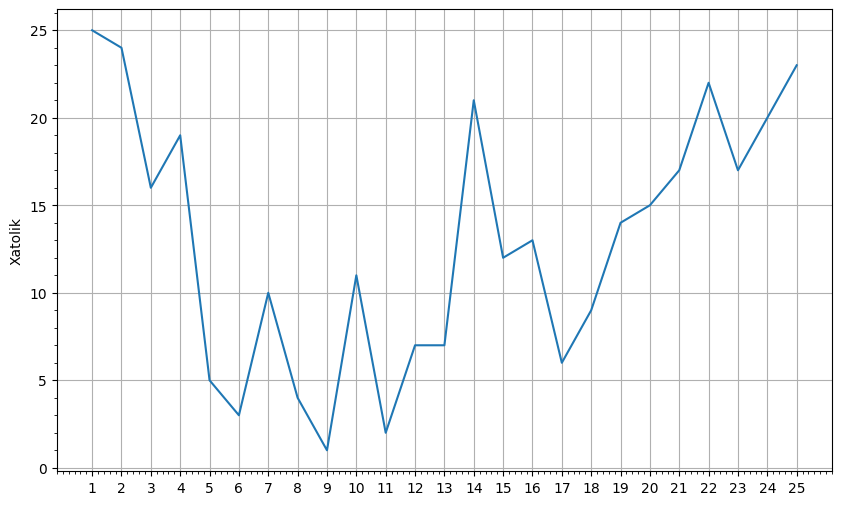

In [59]:
plt.figure(figsize=(10,6))

plt.plot(range(1,26),search.cv_results_['rank_test_score'])
plt.xticks(range(1,26))
plt.ylabel('Xatolik')
plt.grid(which='major')
plt.minorticks_on()
plt.show()

In [ ]:
model_best = KNeighborsClassifier(n_neighbors=9)

model_best.fit(X_train_pro,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",9
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [61]:
predict_best = model_best.predict(X_test_pro)

print(confusion_matrix(y_test,predict_best))
print(classification_report(y_test,predict_best))
print(jaccard_score(y_test,predict_best))

[[98 15]
 [17 75]]
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       113
           1       0.83      0.82      0.82        92

    accuracy                           0.84       205
   macro avg       0.84      0.84      0.84       205
weighted avg       0.84      0.84      0.84       205

0.7009345794392523


In [83]:
from xgboost import XGBClassifier

xgbos = XGBClassifier()

gparm = {
    'n_estimators' :list(range(100,900,100)),
    'learning_rate':[0.01,0.05,0.07,0.1,0.15,0.2,0.3,0.5],
    'max_depth' : list(range(3,11)),
}

gsearch = GridSearchCV(estimator=xgbos,param_grid=gparm,cv=5,verbose=1,scoring=['f1','accuracy','recall','precision'],refit='f1',n_jobs=-1)

gsearch.fit(X_train_pro,y_train)



Fitting 5 folds for each of 512 candidates, totalling 2560 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['f1', 'accuracy', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter cand

In [84]:
gsearch.best_score_

np.float64(0.8825392326909739)

In [85]:
gsearch.best_params_

{'learning_rate': 0.07, 'max_depth': 4, 'n_estimators': 300}

In [86]:
gpre = gsearch.predict(X_test_pro)
print(confusion_matrix(y_test,gpre))

[[95 18]
 [16 76]]


In [87]:
print(classification_report(y_test,gpre))

              precision    recall  f1-score   support

           0       0.86      0.84      0.85       113
           1       0.81      0.83      0.82        92

    accuracy                           0.83       205
   macro avg       0.83      0.83      0.83       205
weighted avg       0.83      0.83      0.83       205



In [ ]:
from sklearn.ensemble import RandomForestClassifier

r_model = RandomForestClassifier()

r_parm = {
  'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 15], 
    'min_samples_split': [2, 5, 10], 
    'min_samples_leaf': [1, 2, 4]
}

r_search = GridSearchCV(estimator=r_model,param_grid=r_parm,verbose=2,cv=5,scoring=['f1','accuracy','recall','precision'],refit='f1',n_jobs=-1)
r_search.fit(X_train_pro,y_train)


In [90]:
r_search.best_params_

{'max_depth': 5,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 200}

In [91]:
r_search.best_score_

np.float64(0.8837839613012027)

In [92]:
r_pre = r_search.predict(X_test_pro)
print(confusion_matrix(y_test,r_pre))
print(classification_report(y_test,r_pre))

[[104   9]
 [ 13  79]]
              precision    recall  f1-score   support

           0       0.89      0.92      0.90       113
           1       0.90      0.86      0.88        92

    accuracy                           0.89       205
   macro avg       0.89      0.89      0.89       205
weighted avg       0.89      0.89      0.89       205



In [113]:
arxiv_jadvali = pd.DataFrame(r_search.cv_results_)

kerakli_ustunlar = [
    'params', 
    'mean_test_f1', 
    'mean_test_recall', 
    'mean_test_accuracy', 
    'mean_test_precision'
]
eng_zor_5_ta = arxiv_jadvali[kerakli_ustunlar].sort_values(by='mean_test_precision', ascending=False).head(5)
eng_zor_5_ta

,params,mean_test_f1,mean_test_recall,mean_test_accuracy,mean_test_precision
37,"{'max_depth': 5, 'min_samples_leaf': 1, 'min_s...",0.883784,0.865193,0.895002,0.903738
50,"{'max_depth': 5, 'min_samples_leaf': 2, 'min_s...",0.880837,0.859860,0.892541,0.903475
70,"{'max_depth': 5, 'min_samples_leaf': 4, 'min_s...",0.883004,0.867860,0.893760,0.899298
47,"{'max_depth': 5, 'min_samples_leaf': 1, 'min_s...",0.880009,0.862491,0.891329,0.898670
48,"{'max_depth': 5, 'min_samples_leaf': 2, 'min_s...",0.881815,0.867789,0.892533,0.896921


In [ ]:
import joblib

joblib.dump(r_search,r"..\models\RandomF_model.joblib")

['..\\models\\RandomF_model.joblib']